# Work on the basis of Session 1 statistic 
1. Data from seaborn official website to practice my session 1 statistics  
    - Diamonds Data
    - Titanic Data

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
Data1 = sns.load_dataset("diamonds")
Data2 = sns.load_dataset("titanic")

print("diamond:", Data1.shape)
print("titanic:", Data2.shape)

diamond: (53940, 10)
titanic: (891, 15)


# work on Diamond Data set


In [3]:
#1. 
Data1.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
#2. 
Data1.shape

(53940, 10)

In [5]:
#3.
Data1.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='str')

In [6]:
#4.
Data1.dtypes

carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

In [7]:
#5.
Data1.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [8]:
#6.
Data1.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [9]:
#7.
Data1['price'].mean()

np.float64(3932.799721913237)

In [10]:
#8.
Data1['price'].median()

np.float64(2401.0)

In [11]:
#9. 
Data1['price'].mode()

0    605
Name: price, dtype: int64

In [12]:
#10.
d1mean = Data1["price"].mean()
d1median = Data1["price"].median()
if d1mean > d1median:
    print("Median Is less and Mean is More,\n distribution is positive and right skewed ")
else:
    print("Mean is less and Median is More,\n  distribution may be negative/left skewed")

Median Is less and Mean is More,
 distribution is positive and right skewed 


The mean price is higher than the median price, suggesting that the distribution of diamond prices is positively (right) skewed. This indicates that a relatively small number of high-priced diamonds pull the mean upward. Therefore, the median may be a more representative measure of the typical diamond price than the mean.

In [13]:
#11.
Data1["price"].min()

np.int64(326)

In [14]:
#12.
Data1["price"].max()

np.int64(18823)

In [15]:
#13.
print(f"range: {Data1["price"].max()-Data1["price"].min()}")

range: 18497


In [16]:
#14.
Data1["price"].var()

np.float64(15915629.42430145)

In [17]:
#15.
Data1["price"].std() # SD
Data1["price"].std(ddof=0)  # Popolation SD
Data1["price"].std(ddof = 1) # Sample SD

np.float64(3989.439738146379)

In [18]:
# #16.
# The SD (standard deviation) of price tells you how spread out the prices are around the average price.

# A small SD means prices tend to be close to the average.
# A large SD means prices vary more widely from the average.

# In other words, it measures the typical amount of variation in price from the mean.


In [19]:
#17.
Q1 = Data1["price"].quantile(0.25)
print("Quantile:",Q1)

Quantile: 950.0


In [20]:
#18.
Q2 = Data1["price"].quantile(0.50)
Q2

np.float64(2401.0)

In [21]:
#19.
Q3 = Data1["price"].quantile(0.75)
Q3

np.float64(5324.25)

In [22]:
#20.
IQR = Q3- Q1
print("IOR:",IQR)

IOR: 4374.25


In [23]:
#21.
print("Lower_bond = ",Q1-1.5*IQR)
LB = Q1-1.5*IQR
LB

Lower_bond =  -5611.375


np.float64(-5611.375)

In [24]:
#22.
print("Upper_bond = ",Q3+1.5*IQR)
UB = Q3+1.5*IQR

Upper_bond =  11885.625


In [25]:
#23. FIND Outlires
price_outliers = Data1[(Data1["price"]  > UB) | (Data1["price"] < LB)]
price_outliers

,carat,cut,color,clarity,depth,table,price,x,y,z
23820,1.17,Ideal,F,VVS1,62.1,57.0,11886,6.82,6.73,4.21
23821,2.08,Ideal,I,SI2,62.0,56.0,11886,8.21,8.10,5.06
23822,1.70,Premium,I,VS2,62.2,58.0,11888,7.65,7.60,4.74
23823,1.09,Ideal,F,IF,61.6,55.0,11888,6.59,6.65,4.08
23824,1.68,Ideal,E,SI2,60.4,55.0,11888,7.79,7.70,4.68
...,...,...,...,...,...,...,...,...,...,...
27745,2.00,Very Good,H,SI1,62.8,57.0,18803,7.95,8.00,5.01
27746,2.07,Ideal,G,SI2,62.5,55.0,18804,8.20,8.13,5.11
27747,1.51,Ideal,G,IF,61.7,55.0,18806,7.37,7.41,4.56
27748,2.00,Very Good,G,SI1,63.5,56.0,18818,7.90,7.97,5.04


In [26]:
#24-28. 
print(f"mean: {Data1["carat"].mean()}\nMedian: {Data1["carat"].median()}\nMode: {Data1["carat"].mode()}\nVariance: {Data1["carat"].var()}\nSD: {Data1["carat"].std()}\nQ1: {Data1["carat"].quantile(0.25)},\nQ2: {Data1["carat"].quantile(0.50)}\nQ3: {Data1["carat"].quantile(0.75)}\nIQR: {Data1["carat"].quantile(0.75)-Data1["carat"].quantile(0.25)}")

mean: 0.7979397478680015
Median: 0.7
Mode: 0    0.3
Name: carat, dtype: float64
Variance: 0.22468665982277328
SD: 0.47401124440541836
Q1: 0.4,
Q2: 0.7
Q3: 1.04
IQR: 0.64


In [27]:
# 29.
UB_of_carat = Data1["carat"].quantile(0.75)+1.5*(Data1["carat"].quantile(0.75) - Data1["carat"].quantile(0.25))
UB_of_carat
Outlier_carat = Data1[Data1["carat"]>UB_of_carat]
print(f"Number of carat outliers (> 2.00): {len(Outlier_carat)}")

Number of carat outliers (> 2.00): 1889


### Now Grouped Stats:

In [28]:
#30.
Data1.head(2)
Data1.groupby("cut")["price"].mean()

cut
Ideal        3457.541970
Premium      4584.257704
Very Good    3981.759891
Good         3928.864452
Fair         4358.757764
Name: price, dtype: float64

In [29]:
#31. 
Data1.groupby(by="cut")["price"].median()

cut
Ideal        1810.0
Premium      3185.0
Very Good    2648.0
Good         3050.5
Fair         3282.0
Name: price, dtype: float64

In [30]:
#32.
Data1.groupby("cut")["price"].std()

cut
Ideal        3808.401172
Premium      4349.204961
Very Good    3935.862161
Good         3681.589584
Fair         3560.386612
Name: price, dtype: float64

In [31]:
#33.
Data1.groupby("cut")["cut"].count()
Data1["cut"].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

In [32]:
#34.
Data1.head(2)
Data1.groupby("color")["price"].mean()

color
D    3169.954096
E    3076.752475
F    3724.886397
G    3999.135671
H    4486.669196
I    5091.874954
J    5323.818020
Name: price, dtype: float64

In [33]:
#35.
Data1.groupby("color")["price"].median()

color
D    1838.0
E    1739.0
F    2343.5
G    2242.0
H    3460.0
I    3730.0
J    4234.0
Name: price, dtype: float64

In [34]:
#36.
Data1.groupby("color")["price"].std()

color
D    3356.590935
E    3344.158685
F    3784.992007
G    4051.102846
H    4215.944171
I    4722.387604
J    4438.187251
Name: price, dtype: float64

In [35]:
Data1.head(2)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31


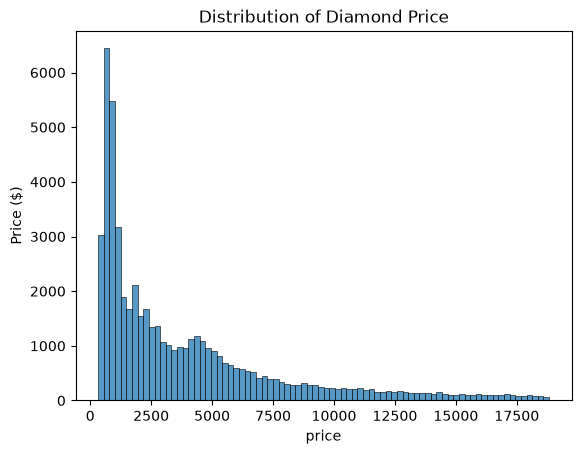

In [37]:
#37. Histogram 
sns.histplot(Data1["price"])
plt.title("Distribution of Diamond Price")
plt.ylabel("Price ($)")
plt.show()


Text(0.5, 1.0, 'Box Blot')

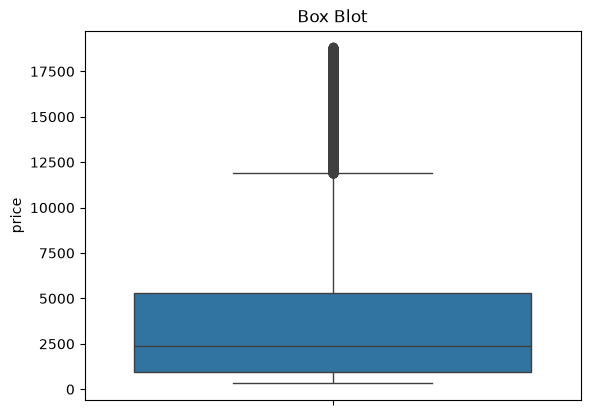

In [51]:
# Box Plot
fig = plt.figure()
sns.boxplot(Data1["price"])
plt.title("Box Blot")


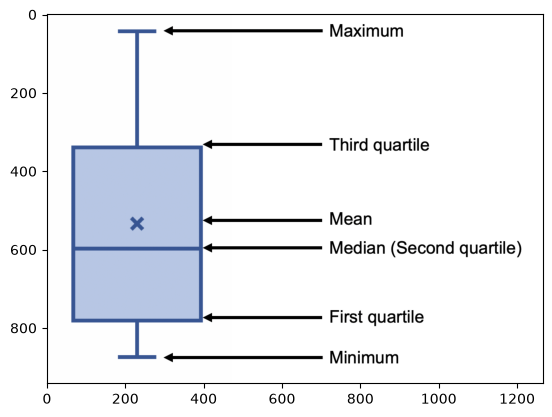

In [ ]:
# Use for Comparing
image = plt.imread("image.png")
plt.imshow(image)

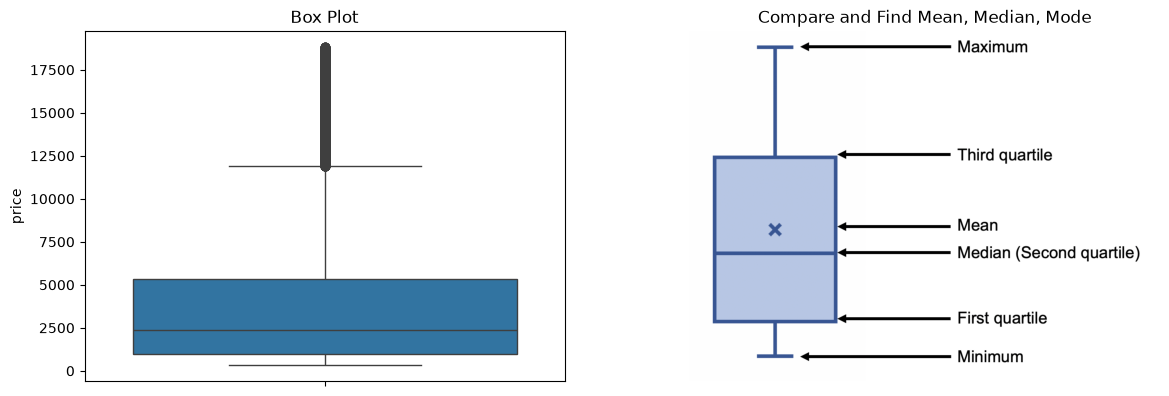

In [ ]:
# improved Version by Use of copy NOtes 
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(12, 5))

# Main plot — left side
ax_main = fig.add_axes([0.05, 0.15, 0.4, 0.7])

sns.boxplot(y=Data1["price"], ax=ax_main)
ax_main.set_title("Box Plot")

# Image — right side
ax_inset = fig.add_axes([0.55, 0.15, 0.4, 0.7])

image1 = plt.imread("image.png")
ax_inset.imshow(image1)
ax_inset.set_title("Compare and Find Mean, Median, Mode")
ax_inset.axis("off")

plt.show()

C:\Users\Aman\AppData\Local\Temp\ipykernel_4820\302519025.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(Data1["carat"],palette="rainbow")


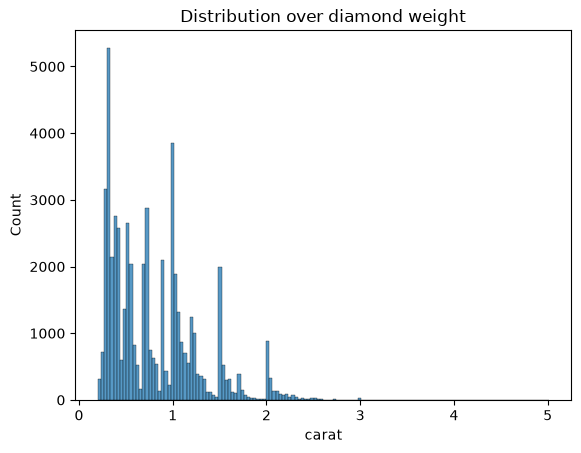

In [ ]:
#39.
sns.histplot(Data1["carat"])
plt.title("Distribution over diamond weight")
plt.show()

C:\Users\Aman\AppData\Local\Temp\ipykernel_4820\3616244391.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cut", y="price", data=Data1,palette="rainbow")


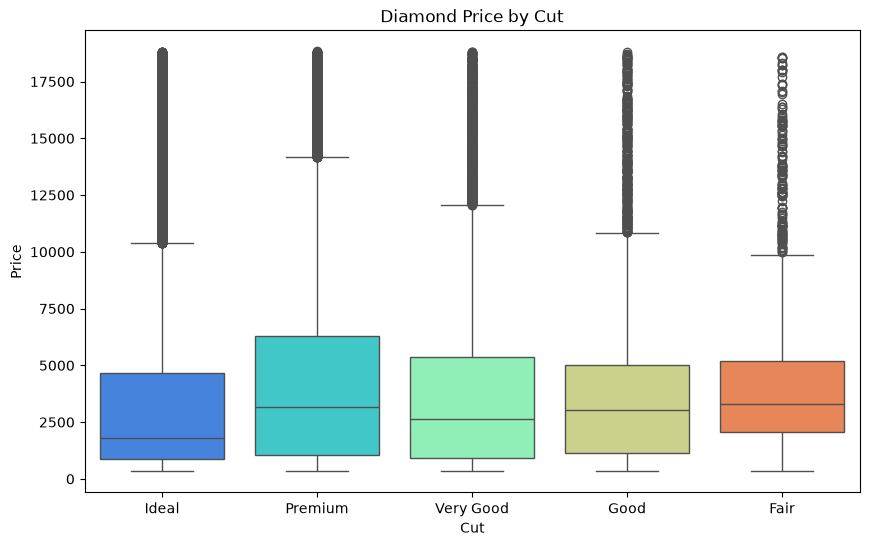

In [90]:
#40.
plt.figure(figsize=(10, 6))
sns.boxplot(x="cut", y="price", data=Data1,palette="rainbow")
plt.title("Diamond Price by Cut")
plt.xlabel("Cut")
plt.ylabel("Price")
plt.show()

<Axes: xlabel='carat', ylabel='price'>

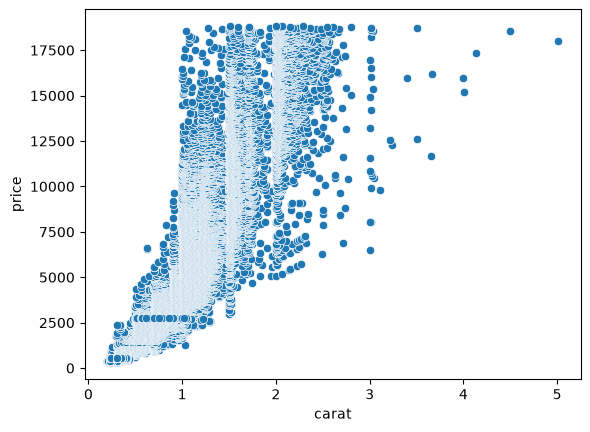

In [ ]:
#41 (1)
sns.scatterplot(x = "carat",y="price",data=Data1)

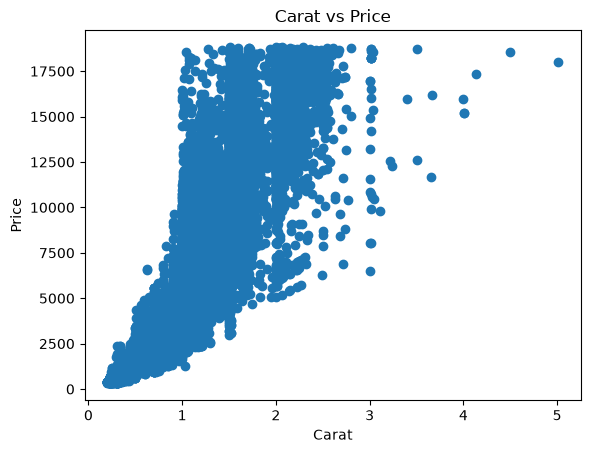

In [ ]:
#41 (2)
plt.scatter(Data1["carat"], Data1["price"])

plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Carat vs Price")

plt.show()

In [94]:
# 42.
Data2.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [95]:
# 43.
Data2.shape


(891, 15)

In [96]:
# 44.
Data2.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [97]:
Data2.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [ ]:
#46
Data2.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [103]:
#47
Data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [ ]:
# Q48-Q55
mean_age = Data2["age"].mean()
median_age = Data2["age"].median()
mode_age = Data2["age"].mode()[0]
min_age = Data2["age"].min()
max_age = Data2["age"].max()
range_age = max_age - min_age
var_age = Data2["age"].var()
std_age = Data2["age"].std()

print("Mean Age:", mean_age)
print("Median Age:", median_age)
print("Mode Age:", mode_age)
print("Minimum Age:", min_age)
print("Maximum Age:", max_age)
print("Range:", range_age)
print("Variance:", var_age)
print("Standard Deviation:", std_age)

Mean Age: 29.69911764705882
Median Age: 28.0
Mode Age: 24.0
Minimum Age: 0.42
Maximum Age: 80.0
Range: 79.58
Variance: 211.01912474630802
Standard Deviation: 14.526497332334042


In [112]:
# Q56-Q60
q1_age = Data2["age"].quantile(0.25)
q2_age = Data2["age"].quantile(0.50)
q3_age = Data2["age"].quantile(0.75)

iqr_age = q3_age - q1_age

lower_age = q1_age - 1.5 * iqr_age
upper_age = q3_age + 1.5 * iqr_age

age_outliers = Data2[Data2["age"] > upper_age]

print("Q1:", q1_age)
print("Q2:", q2_age)
print("Q3:", q3_age)
print("IQR:", iqr_age)
print("Lower Boundary:", lower_age)
print("Upper Boundary:", upper_age)
print("Number of age outliers:", len(age_outliers))

Q1: 20.125
Q2: 28.0
Q3: 38.0
IQR: 17.875
Lower Boundary: -6.6875
Upper Boundary: 64.8125
Number of age outliers: 11


In [113]:
# Q61-Q68
mean_fare = Data2["fare"].mean()
median_fare = Data2["fare"].median()
min_fare = Data2["fare"].min()
max_fare = Data2["fare"].max()
range_fare = max_fare - min_fare
var_fare = Data2["fare"].var()
std_fare = Data2["fare"].std()

q1_fare = Data2["fare"].quantile(0.25)
q2_fare = Data2["fare"].quantile(0.50)
q3_fare = Data2["fare"].quantile(0.75)
iqr_fare = q3_fare - q1_fare

upper_fare = q3_fare + 1.5 * iqr_fare
outliers_fare = Data2[Data2["fare"] > upper_fare]

print("Mean Fare:", mean_fare)
print("Median Fare:", median_fare)
print("Minimum Fare:", min_fare)
print("Maximum Fare:", max_fare)
print("Range:", range_fare)
print("Variance:", var_fare)
print("Standard Deviation:", std_fare)
print("Q1:", q1_fare)
print("Q2:", q2_fare)
print("Q3:", q3_fare)
print("IQR:", iqr_fare)
print("Upper Boundary:", upper_fare)
print("Number of fare outliers:", len(outliers_fare))

Mean Fare: 32.204207968574636
Median Fare: 14.4542
Minimum Fare: 0.0
Maximum Fare: 512.3292
Range: 512.3292
Variance: 2469.436845743116
Standard Deviation: 49.6934285971809
Q1: 7.9104
Q2: 14.4542
Q3: 31.0
IQR: 23.0896
Upper Boundary: 65.6344
Number of fare outliers: 116


In [ ]:
# Q69-Q72
AVG_age = Data2.groupby("sex")["age"].mean()
Median_age = Data2.groupby("sex")["age"].median()
SD_age = Data2.groupby("sex")["age"].std()
Avg_fare =Data2.groupby("sex")["fare"].mean()
print("Avg_age:",AVG_age,"\n")
print("Median_age:",Median_age,"\n")
print("Sd_of_age:",SD_age,"\n")
print("Avg_fare:",Avg_fare)


Avg_age: sex
female    27.915709
male      30.726645
Name: age, dtype: float64 

Median_age: sex
female    27.0
male      29.0
Name: age, dtype: float64 

Sd_of_age: sex
female    14.110146
male      14.678201
Name: age, dtype: float64 

Avg_fare: sex
female    44.479818
male      25.523893
Name: fare, dtype: float64


In [127]:
# Q73. by passenger class
Avg_f = Data2.groupby("pclass")["fare"].mean()
print("Avg_fare_by_class:",Avg_f)

Avg_fare_by_class: pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64


In [128]:
# Q74-Q75
print(Data2.groupby("class", observed=False)["fare"].agg(["median", "std"]))

print(Data2.groupby("class", observed=False)["age"].mean())

         median        std
class                     
First   60.2875  78.380373
Second  14.2500  13.417399
Third    8.0500  11.778142
class
First     38.233441
Second    29.877630
Third     25.140620
Name: age, dtype: float64


(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

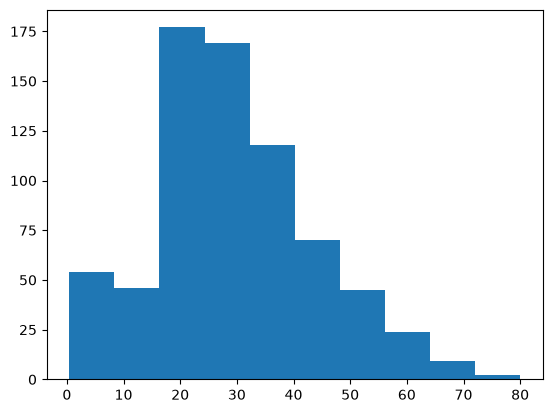

In [ ]:
# Q77.(1)
plt.hist(Data2["age"])


Text(0.5, 1.0, 'Distribution of passenger ages')

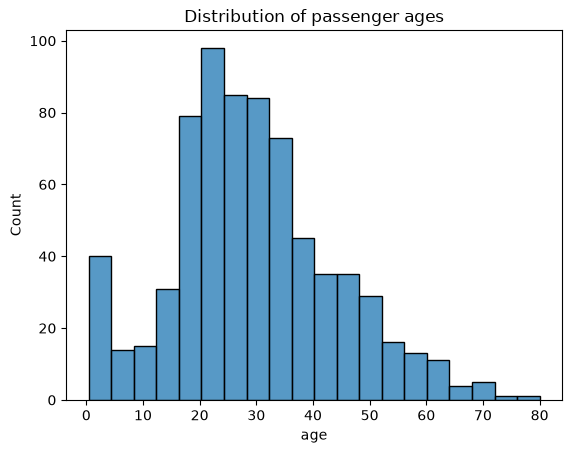

In [136]:
#77(2)
sns.histplot(x = Data2["age"],data= Data2)
plt.title("Distribution of passenger ages")

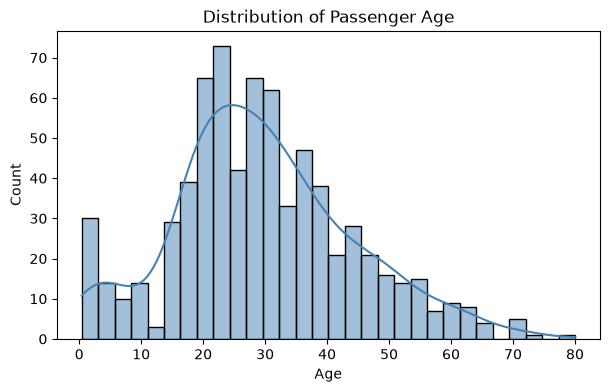

In [141]:
#77(3)
plt.figure(figsize=(7, 4))
sns.histplot(Data2["age"].dropna(), bins=30, kde=True, color="steelblue")
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.show()

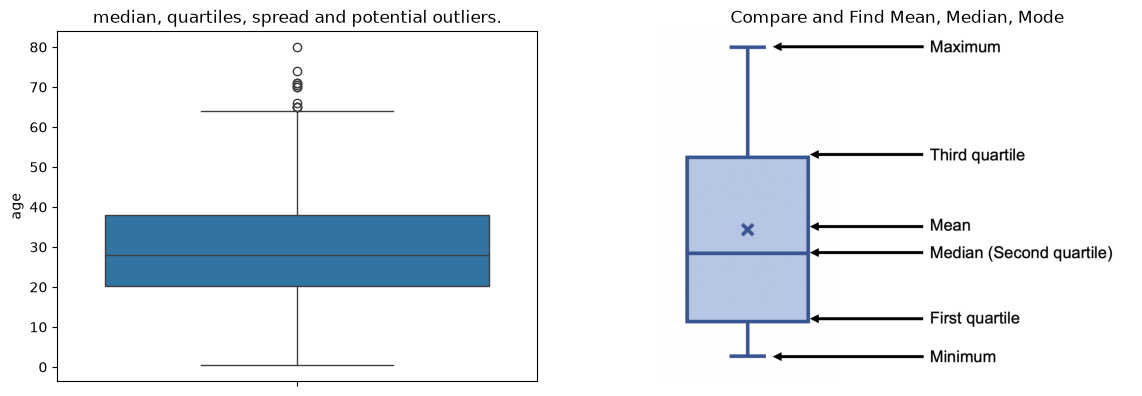

In [146]:
# Q78
fig = plt.figure(figsize=(12, 5))
ax_main = fig.add_axes([0.05, 0.15, 0.4, 0.7])
sns.boxplot(y = Data2["age"],ax=ax_main)
plt.title("median, quartiles, spread and potential outliers.")

ax_inset = fig.add_axes([0.55, 0.15, 0.4, 0.7])
image1 = plt.imread("image.png")
ax_inset.imshow(image1)
ax_inset.set_title("Compare and Find Mean, Median, Mode")
ax_inset.axis("off")

plt.show()
## Outliers 80 pr h mtlb kuch buddhe bhi h 


Text(0.5, 0, 'FARE ($)')

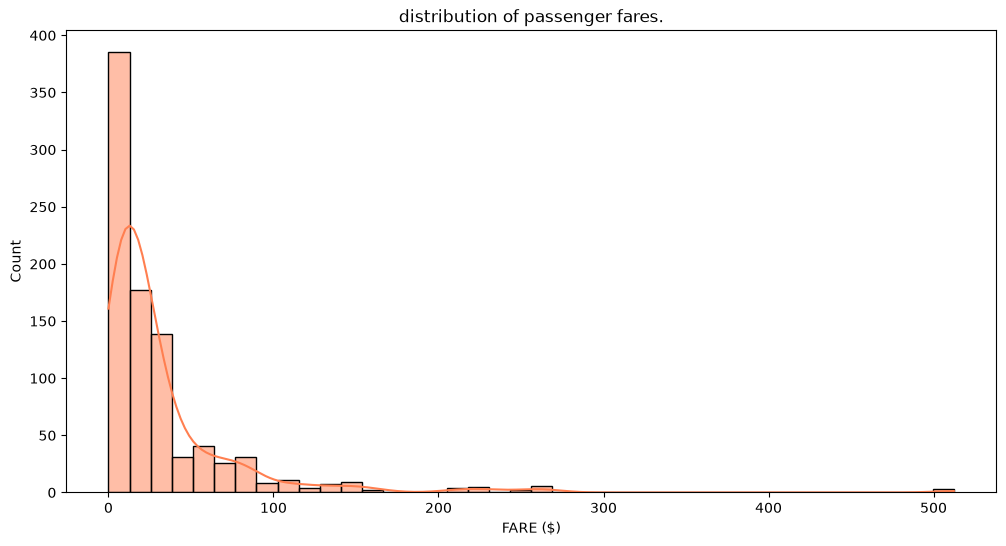

In [154]:
#79.
plt.figure(figsize=(12,6))
sns.histplot(Data2["fare"], bins=40, kde=True, color="coral")
plt.title("distribution of passenger fares.")
plt.xlabel("FARE ($)")

Text(0.5, 1.0, 'spread and potential fare outliers')

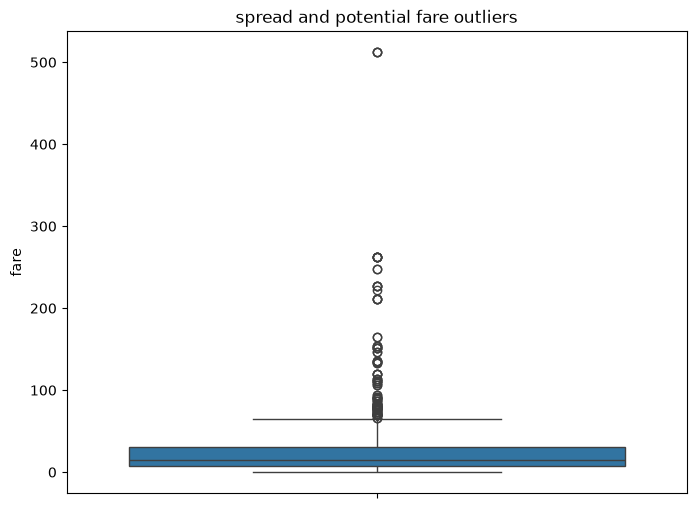

In [158]:
#80.
plt.figure(figsize=(8,6))
sns.boxplot(Data2['fare'])
plt.title("spread and potential fare outliers")

Text(0.5, 1.0, 'Fare Distribution Across Passenger Classes')

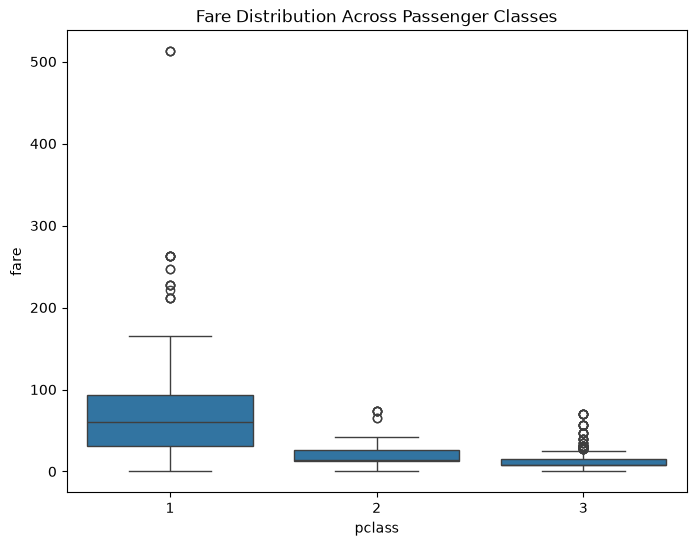

In [160]:
#81
plt.figure(figsize=(8,6))
sns.boxplot(data=Data2,x = "pclass",y = "fare")
plt.title("Fare Distribution Across Passenger Classes")

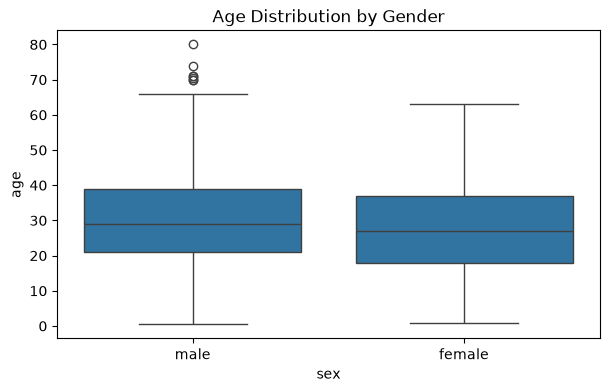

In [162]:
#82.
plt.figure(figsize=(7, 4))
sns.boxplot(data=Data2, x="sex", y="age")
plt.title("Age Distribution by Gender")
plt.show()

C:\Users\Aman\AppData\Local\Temp\ipykernel_4820\3827136905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Data2, x="class", palette="Blues")


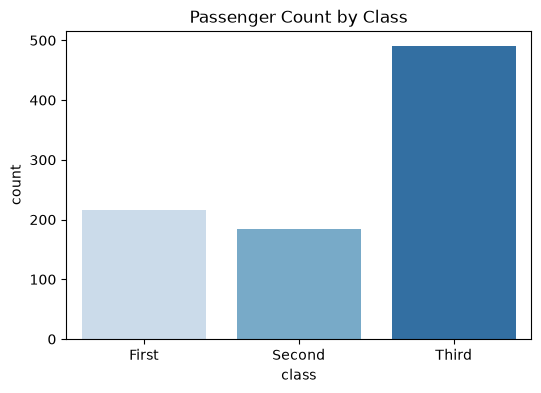

In [ ]:
#83.
plt.figure(figsize=(6, 4))
sns.countplot(data=Data2, x="class", palette="Blues")
plt.title("Passenger Count by Class")
plt.show()

C:\Users\Aman\AppData\Local\Temp\ipykernel_4820\2664599489.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Data2, x="survived", palette="Set2")


<Axes: xlabel='survived', ylabel='count'>

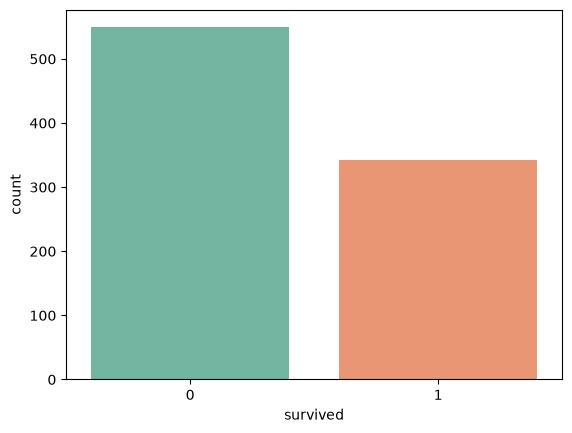

In [172]:
# Q84 
#       survived = 0
#       survived = 1
sns.countplot(data=Data2, x="survived", palette="Set2")




<Axes: xlabel='price', ylabel='Count'>

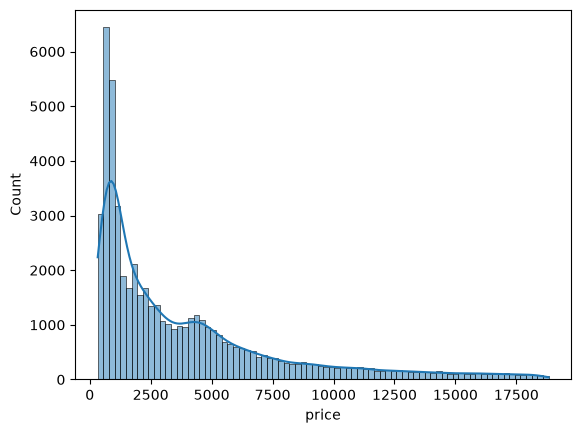

In [ ]:
#85-86
sns.histplot(Data1["price"],kde=True)

Explanation by me: this graph is left sided which is posotively skewed
Explanation from Chatgpt:
Normal distribution ek perfect ghanti ke aakar (bell-shaped) jaisi hoti hai, jisme Mean, Median aur Mode sabhi center mein barabar hote hain.Jab hum price ka histogram ya KDE plot dekhte hain, toh maximum diamonds saste rate (around $600–$2,000) ke paas clustered hain.   Graph right side mein $18,000 tak lamba khichta chala jata hai. Is asymmetrical shape ki wajah se yeh normal distribution nahi hai.


<Axes: xlabel='carat', ylabel='price'>

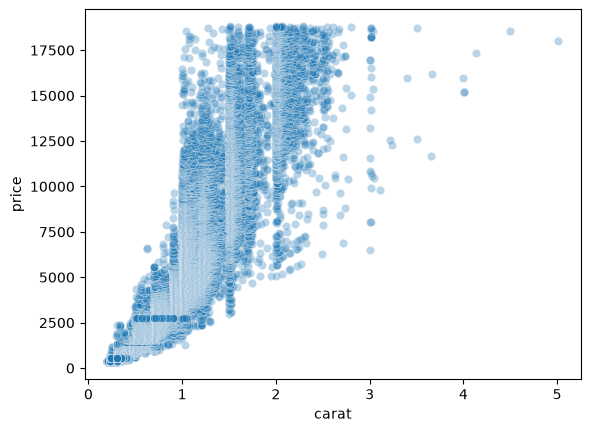

In [ ]:
#87
sns.scatterplot(x="carat",y="price",data=Data1,alpha=0.3)
#Haan, carat aur price ke beech ek strong positive, non-linear (curved) relationship hai.

In [183]:
# Q88
Data1.groupby("cut",observed=False)["price"].std().sort_values(ascending=False).head(1)

cut
Premium    4349.204961
Name: price, dtype: float64

In [ ]:
# Q89 
# 1. Price ka CV
cv_price = (Data1['price'].std() / Data1['price'].mean()) * 100

# 2. Carat ka CV
cv_carat = (Data1['carat'].std() / Data1['carat'].mean()) * 100

print(f"CV of Price: {cv_price:.2f}%")
print(f"CV of Carat: {cv_carat:.2f}%")


# Result: Relative terms mein price significantly zyada dispersed hai.

CV of Price: 101.44%
CV of Carat: 59.40%


Skew:   0.39


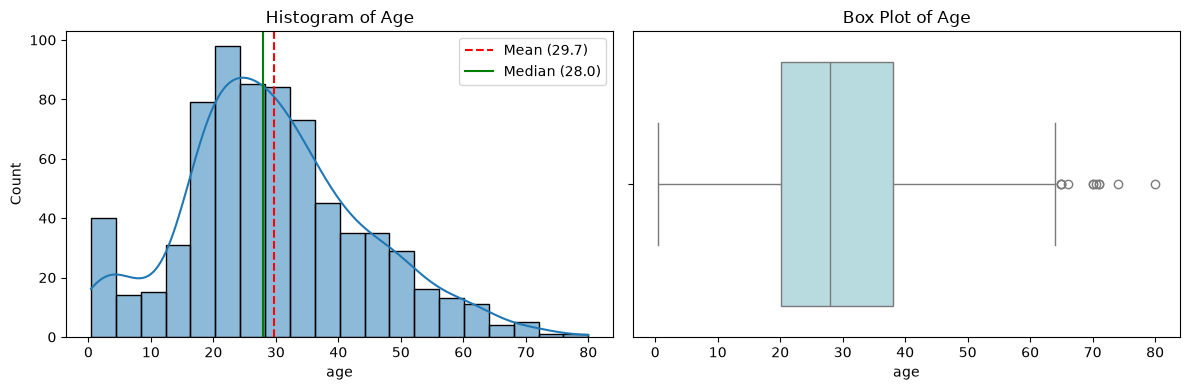

In [206]:
#90.
skew_age = Data2['age'].skew()
print(f"Skew:   {skew_age:.2f}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=Data2["age"],kde=True,ax=axes[0])
axes[0].axvline(
    mean_age, color='red', linestyle='--', label=f'Mean ({mean_age:.1f})'
)
axes[0].axvline(
    median_age,
    color='green',
    linestyle='-',
    label=f'Median ({median_age:.1f})')
axes[0].set_title('Histogram of Age')
axes[0].legend()
# 2. Box Plot
sns.boxplot(x=Data2['age'], ax=axes[1], color='powderblue')
axes[1].set_title('Box Plot of Age')

plt.tight_layout()
plt.show()


# Result: positive skewed

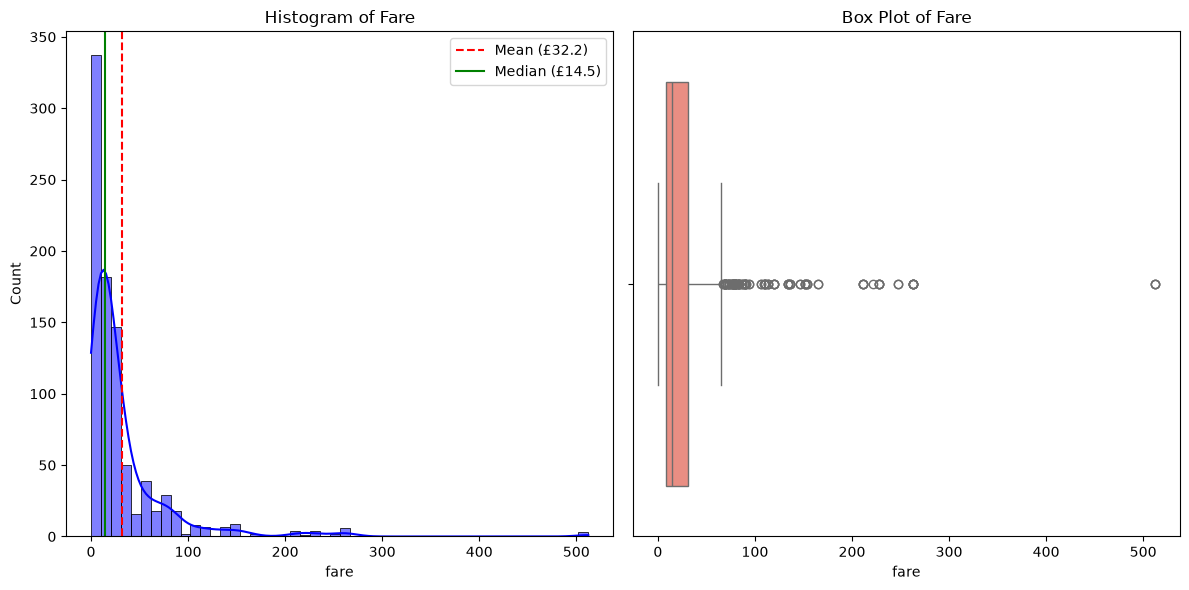

In [ ]:
#Q91
fare_mean = Data2["fare"].mean()
fare_median = Data2["fare"].median()
fare_skew = Data2["fare"].skew()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Histogram with label for legend
sns.histplot(Data2["fare"], bins=50, ax=axes[0], kde=True, color="blue")
axes[0].axvline(
    x=fare_mean,
    color="red",
    linestyle="--",
    label=f"Mean (£{fare_mean:.1f})",
)
axes[0].axvline(
    x=fare_median,
    color="green",
    linestyle="-",
    label=f"Median (£{fare_median:.1f})",
)
axes[0].set_title("Histogram of Fare")
axes[0].legend()

# Box Plot
sns.boxplot(x=Data2["fare"], ax=axes[1], color="salmon")
axes[1].set_title("Box Plot of Fare")

plt.tight_layout()
plt.show()

"""Answer: fare symmetric nahi hai; yeh extremely positively skewed (right-skewed) hai. Adhiktar passengers ne saste tickets liye the, jabki kuch passengers ke bohot mehenge fares (£100–£512+) ki wajah se distribution right side mein lambi tail banati hai."""

In [ ]:
#92
std_pc = Data2.groupby("pclass")["fare"].std() 
std_pc

pclass
1    78.380373
2    13.417399
3    11.778142
Name: fare, dtype: float64

In [262]:
# Har class ke liye fare ka standard deviation (SD) calculate karte hain
fare_std_by_class = Data2.groupby("class", observed=False)["fare"].std().sort_values(ascending=False)

print("Standard Deviation of Fare by Class:")
print(fare_std_by_class)

# Highest variation wali class nikalte hain
highest_variation_class = fare_std_by_class.index[0]
print(f"\nClass with greatest variation: {highest_variation_class}")

Standard Deviation of Fare by Class:
class
First     78.380373
Second    13.417399
Third     11.778142
Name: fare, dtype: float64

Class with greatest variation: First


Age Outliers (> 64.81 years): 11
Fare Outliers (> £65.63):    116


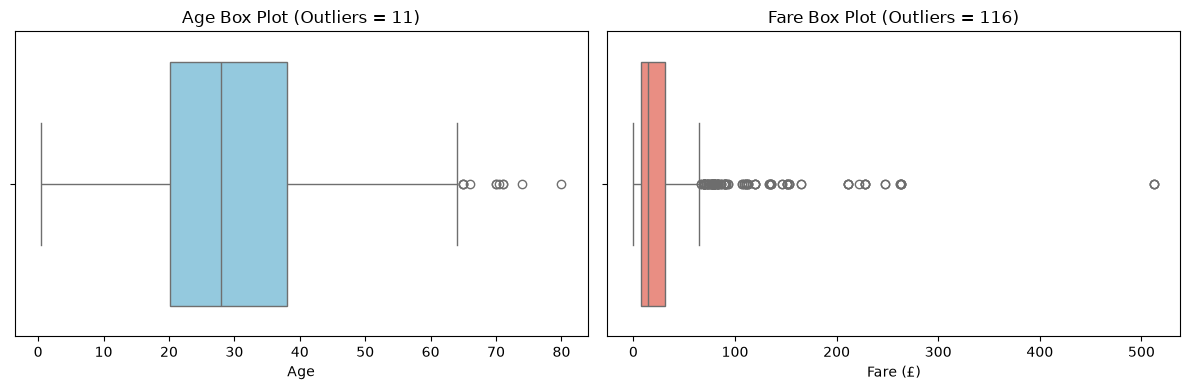

In [264]:
#93
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Age ke Outliers calculate karte hain
q1_age = Data2['age'].quantile(0.25)
q3_age = Data2['age'].quantile(0.75)
iqr_age = q3_age - q1_age
upper_age = q3_age + 1.5 * iqr_age
age_outliers_count = (Data2['age'] > upper_age).sum()

# 2. Fare ke Outliers calculate karte hain
q1_fare = Data2['fare'].quantile(0.25)
q3_fare = Data2['fare'].quantile(0.75)
iqr_fare = q3_fare - q1_fare
upper_fare = q3_fare + 1.5 * iqr_fare
fare_outliers_count = (Data2['fare'] > upper_fare).sum()

print(f"Age Outliers (> {upper_age:.2f} years): {age_outliers_count}")
print(f"Fare Outliers (> £{upper_fare:.2f}):    {fare_outliers_count}")

# 3. Box Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age Box Plot
sns.boxplot(x=Data2['age'], ax=axes[0], color='skyblue')
axes[0].set_title(f'Age Box Plot (Outliers = {age_outliers_count})')
axes[0].set_xlabel('Age')

# Fare Box Plot
sns.boxplot(x=Data2['fare'], ax=axes[1], color='salmon')
axes[1].set_title(f'Fare Box Plot (Outliers = {fare_outliers_count})')
axes[1].set_xlabel('Fare (£)')

plt.tight_layout()
plt.show()

# Result:fare variable mein zyada obvious aur extreme outliers hain. Jahan age mein sirf 11 outliers hain jo boundary ke qareeb hain, wahin fare mein 116 outliers hain jo IQR boundary (£65.63) se bohot aage £500+ tak bikhre hue hain


## Last questions plot only

C:\Users\Aman\AppData\Local\Temp\ipykernel_4820\3090421326.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Data1, x='cut', y='price', ax=axes[1, 0], palette='Set2')


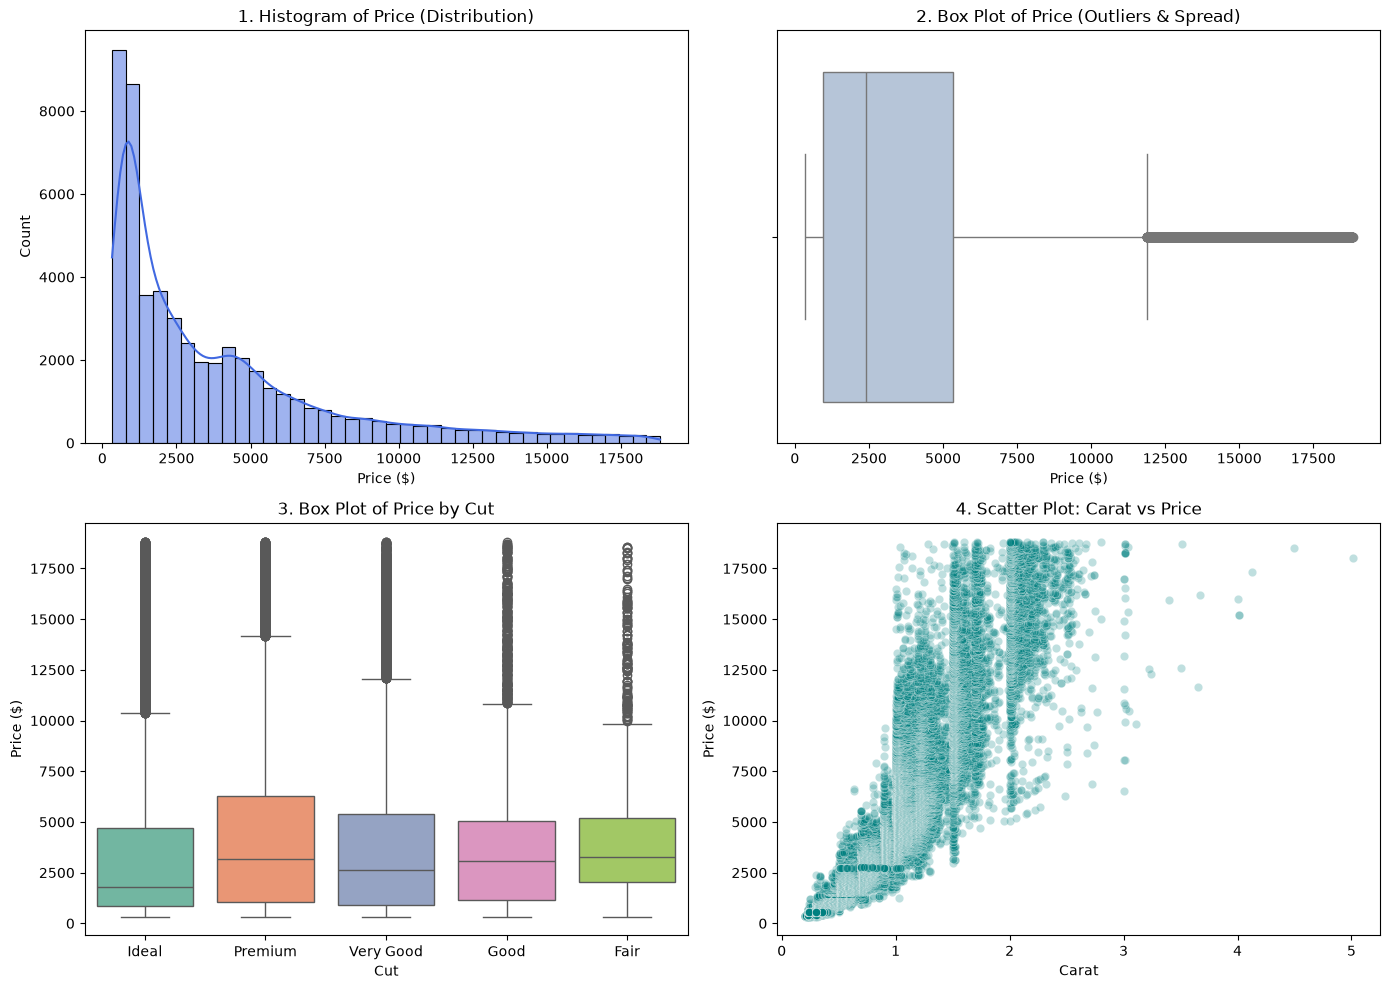

In [265]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of price
sns.histplot(Data1['price'], bins=40, kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('1. Histogram of Price (Distribution)')
axes[0, 0].set_xlabel('Price ($)')

# 2. Box plot of price
sns.boxplot(x=Data1['price'], ax=axes[0, 1], color='lightsteelblue')
axes[0, 1].set_title('2. Box Plot of Price (Outliers & Spread)')
axes[0, 1].set_xlabel('Price ($)')

# 3. Box plot of price by cut
sns.boxplot(data=Data1, x='cut', y='price', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('3. Box Plot of Price by Cut')
axes[1, 0].set_xlabel('Cut')
axes[1, 0].set_ylabel('Price ($)')

# 4. Scatter plot of carat vs price
sns.scatterplot(data=Data1, x='carat', y='price', ax=axes[1, 1], alpha=0.25, color='teal')
axes[1, 1].set_title('4. Scatter Plot: Carat vs Price')
axes[1, 1].set_xlabel('Carat')
axes[1, 1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()